In [219]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [221]:
df=pd.read_csv('Breast_Cancer.csv')

In [223]:
# 1. Basic Inspection
# 1.1 Displaying some records
display(df.head())
print('-------------------------------------------------------------------')
# 1.2 Checking information 
df.info() 
print('-------------------------------------------------------------------')
# 1.3 Checking the shape 
print('Shape:',df.shape)  
print('-------------------------------------------------------------------')
# 1.4 Checking null value 
print('Missing values per column')
display(df.isnull().sum())
print('-------------------------------------------------------------------')
# 1.5 Checking duplicates
print ('No of duplicates:', df.duplicated().sum())
df = df.drop_duplicates()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


-------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

-------------------------------------------------------------------
No of duplicates: 1


Age Group
50-59       1386
40-49       1196
60-69       1139
Under 40     302
70+            0
Name: count, dtype: int64


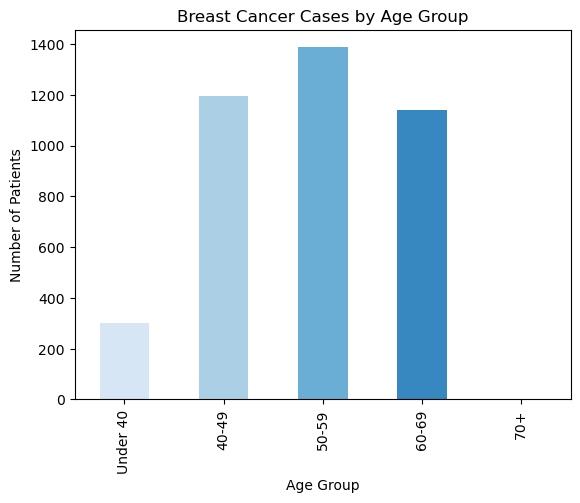

In [237]:
# 2. Exploratory Data Analysis
# 2.1 Categrize the age into groups
bins = [0,40,50,60,70,100]
labels = ["Under 40","40-49","50-59","60-69","70+"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)
print(df["Age Group"].value_counts())

# Visualization of patients by age group
age_counts = df["Age Group"].value_counts().sort_index()

colors = sns.color_palette("Blues", len(age_counts))
age_counts.plot(kind="bar", color=colors)
plt.title("Breast Cancer Cases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.show()

Status
Alive    3407
Dead      616
Name: count, dtype: int64


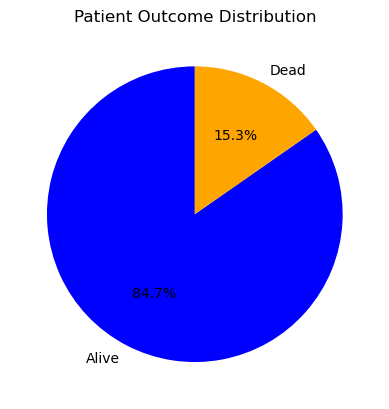

In [227]:
# 2.2 Survival and dead distribution analysis
print(df["Status"].value_counts())
df["Status"].value_counts().plot(kind="pie", colors=['blue', 'orange'], autopct="%1.1f%%", startangle=90)
plt.title("Patient Outcome Distribution")
plt.ylabel("")
plt.show()

In [229]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Age', 'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months', 'Status', 'Age Group']


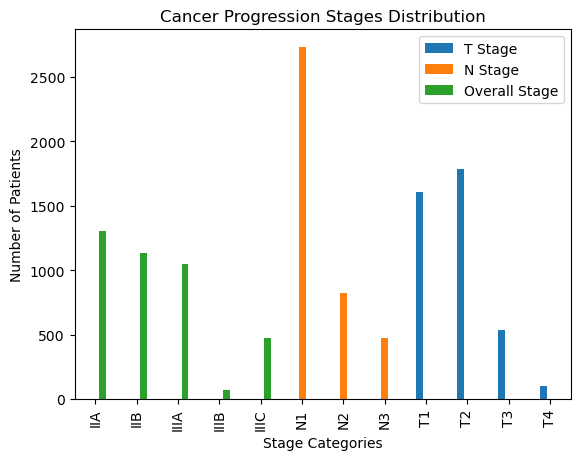

In [231]:
# 2.3 Cancer progression stage category analysis(T, N, Overall stage)
t_counts = df["T Stage"].value_counts()
n_counts = df["N Stage"].value_counts()
s_counts = df["6th Stage"].value_counts()

stage_df = pd.DataFrame({
    "T Stage": t_counts,
    "N Stage": n_counts,
    "Overall Stage": s_counts
}).fillna(0)

stage_df.plot(kind="bar")

plt.title("Cancer Progression Stages Distribution")
plt.xlabel("Stage Categories")
plt.ylabel("Number of Patients")

plt.show()

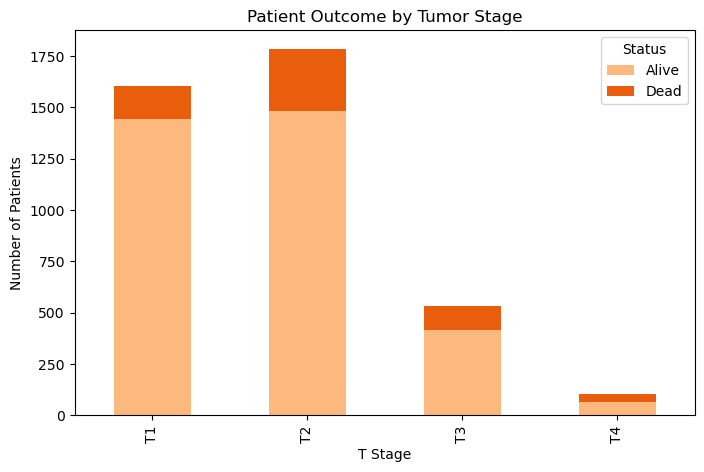

In [232]:
# 2.4 Survival and death rate for each stage

#2.4.1 T Stage
stage_status = pd.crosstab(df["T Stage"], df["Status"])

palette = sns.color_palette("Oranges", 2)
stage_status.plot(
    kind="bar",
    stacked=True,
    color=palette,
    figsize=(8,5)
)

plt.title("Patient Outcome by Tumor Stage")
plt.xlabel("T Stage")
plt.ylabel("Number of Patients")

plt.show()

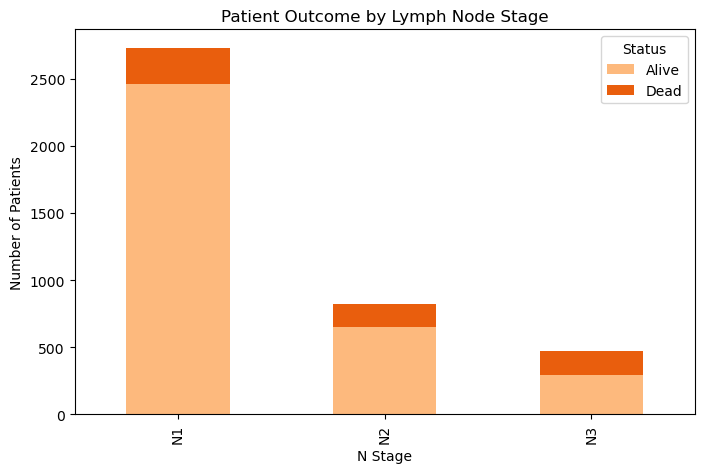

In [235]:
# 2.4.2 N Stage
stage_status = pd.crosstab(df["N Stage"], df["Status"])
palette = sns.color_palette("Oranges", 2)
stage_status.plot(
    kind="bar",
    stacked=True,
    color=palette,
    figsize=(8,5)
)

plt.title("Patient Outcome by Lymph Node Stage")
plt.xlabel("N Stage")
plt.ylabel("Number of Patients")

plt.show()

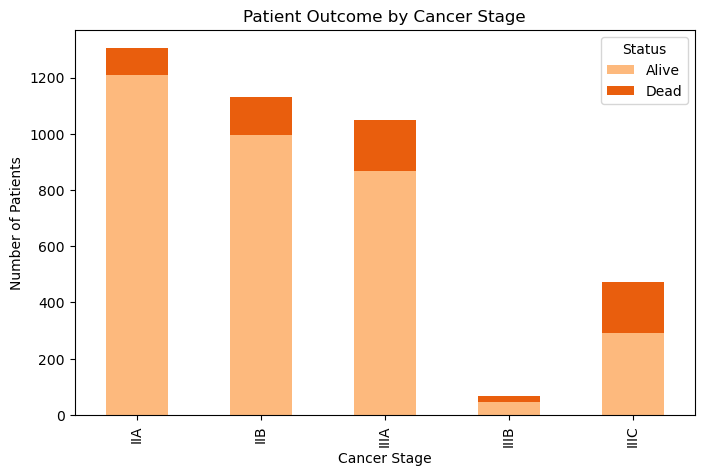

In [217]:
# 2.4.3 Overall Cancer Stage
stage_status = pd.crosstab(df["6th Stage"], df["Status"])

palette = sns.color_palette("Oranges", 2)
stage_status.plot(
    kind="bar",
    stacked=True,
    color=palette,
    figsize=(8,5)
)

plt.title("Patient Outcome by Cancer Stage")
plt.xlabel("Cancer Stage")
plt.ylabel("Number of Patients")

plt.show()